# Android Games Dataset — Preprocessing Pipeline
Clean, single-run version. Run cells top to bottom, once.

## 1. Imports and Load Data

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler , RobustScaler , LabelEncoder
from sklearn.model_selection import train_test_split

df = pd.read_csv(r"android_games_eda_ready.csv")
print("Shape:", df.shape)
df.info()

Shape: (10150, 57)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10150 entries, 0 to 10149
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   game_id                   10150 non-null  int64  
 1   game_name                 10150 non-null  object 
 2   developer_name            10150 non-null  object 
 3   package_name              10150 non-null  object 
 4   genre                     10150 non-null  object 
 5   sub_genre                 10150 non-null  object 
 6   monetization_model        10150 non-null  object 
 7   contains_ads              10150 non-null  object 
 8   has_in_app_purchases      10150 non-null  object 
 9   multiplayer_support       6084 non-null   object 
 10  age_rating                10150 non-null  object 
 11  art_style                 10150 non-null  object 
 12  engine_used               10150 non-null  object 
 13  region_focus              10150 non-null  

In [49]:
df.head()

,game_id,game_name,developer_name,package_name,genre,sub_genre,monetization_model,contains_ads,has_in_app_purchases,multiplayer_support,...,has_seasonal_event,cross_platform_available,cloud_save_support,is_hit_game,post_30d_revenue_usd,post_30d_rating_count,featured_duration_days,store_platform,country_code_primary,row_checksum_id
0,622,Game_622_Arena,Studio_205,com.studio1664.game622,Casual,Party Game,Freemium,Yes,Yes,NaN,...,False,True,True,0,9963.75,6328,NaN,Android,IN,CHK_100621
1,4386,Game_4386_Rush,Studio_923,com.studio1615.game4386,RPG,Idle RPG,Free,Yes,No,Online,...,False,True,False,0,17880.43,9346,NaN,Android,IN,CHK_104385
2,6795,Game_6795_Tycoon,Studio_921,com.studio44.game6795,RPG,Idle RPG,Free,Yes,No,NaN,...,True,False,False,0,6060.03,4096,7.0,Android,BR,CHK_106794
3,4563,Game_4563_Quest,Studio_1873,com.studio1353.game4563,Casual,Idle Clicker,Paid,No,Yes,NaN,...,False,False,False,0,816621.72,12402,NaN,Android,US,CHK_104562
4,9265,Game_9265_Legends,Studio_1608,com.studio1308.game9265,RPG,MMORPG,Free,Yes,No,NaN,...,True,False,True,0,159839.20,7517,NaN,Android,IN,CHK_109264


## 2. Drop Identifier Columns, THEN Remove Duplicates
IDs are dropped first so duplicate detection is based on the actual game data, not on
unique-looking ID columns that could mask real duplicate rows.

In [50]:
df = df.drop(columns=['game_id', 'game_name', 'package_name', 'row_checksum_id'])

print("Duplicate rows found:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)

print(df.isnull().sum())

Duplicate rows found: 150
Shape after removing duplicates: (10000, 53)
developer_name                 0
genre                          0
sub_genre                      0
monetization_model             0
contains_ads                   0
has_in_app_purchases           0
multiplayer_support         4013
age_rating                     0
art_style                      0
engine_used                    0
region_focus                   0
publisher_tier                 0
event_theme                 7577
release_date                   0
soft_launch_date            1000
last_update_date               0
was_featured_on_store          0
featured_start_date         6697
featured_end_date           6697
price_usd                      0
downloads                      0
retention_day1_pct             0
retention_day7_pct             0
retention_day30_pct            0
active_users_30d               0
avg_session_minutes            0
avg_daily_sessions             0
crash_rate_pct                 0
apk_s

## 3. Handle Missing Values (placeholders only — no leakage risk)
Structurally missing columns (NaN means the feature doesn't apply) -> fill with a placeholder.
Genuinely missing **numeric** columns (`marketing_spend_usd`, `cpi_usd`, `arppu_usd`) are handled
later, **after the train/test split**, using the train median only — see Section 6.

In [51]:
df['soft_launch_date'] = df['soft_launch_date'].fillna('No Soft Launch')
df.drop("featured_start_date" , axis = 1, inplace = True)
df.drop("featured_end_date" , axis = 1, inplace = True)
df.drop("featured_duration_days" , axis = 1, inplace = True)
df.drop("event_theme" , axis = 1, inplace = True)
df.drop("multiplayer_support" , axis = 1, inplace = True)

print("Nulls remaining (should only be the 3 numeric cols handled after split):")
print(df.isnull().sum()[df.isnull().sum() > 0])

Nulls remaining (should only be the 3 numeric cols handled after split):
marketing_spend_usd    800
cpi_usd                500
arppu_usd              700
dtype: int64


## 4. Drop Zero-Variance and Leakage Columns and unimportant columns
- `store_platform`: same value in every row (`'Android'`), no information -> drop.
- `price_usd` is **kept**: it has 688 unique values, and ~2,000 games have a nonzero price —
  paid vs. free is a genuinely informative feature, not a constant column.
- `post_30d_revenue_usd`, `post_30d_rating_count`: measured *after* outcome is known —
  leaks the answer when predicting `is_hit_game`.

In [52]:
print("price_usd unique values:", df['price_usd'].nunique(), "| nonzero price rows:", (df['price_usd'] != 0).sum())
print("store_platform unique values:", df['store_platform'].unique())

df = df.drop(columns=['store_platform', 'post_30d_revenue_usd', 'post_30d_rating_count','downloads','total_revenue_usd','release_date' , 'soft_launch_date','last_update_date'])

price_usd unique values: 688 | nonzero price rows: 1966
store_platform unique values: ['Android']


## 5. Train/Test Split
Split BEFORE any statistic (median, value_counts, IQR bounds, scaler) is computed,
so nothing about the test set can influence preprocessing.

`stratify=y` keeps the same hit/non-hit ratio in both train and test — important here since
`is_hit_game` is heavily imbalanced (~2% positive class).

In [53]:
X = df.drop(columns=['is_hit_game'])
y = df['is_hit_game']

print("is_hit_game class balance:")
print(y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)
print("Train class balance:", y_train.value_counts(normalize=True).to_dict())
print("Test class balance:", y_test.value_counts(normalize=True).to_dict())

is_hit_game class balance:
is_hit_game
0    0.98
1    0.02
Name: proportion, dtype: float64
(8000, 39) (2000, 39)
Train class balance: {0: 0.98, 1: 0.02}
Test class balance: {0: 0.98, 1: 0.02}


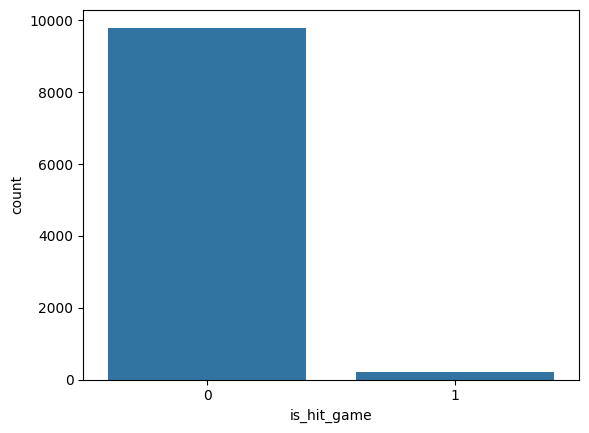

In [54]:
sns.countplot(x=y)
plt.xlabel("is_hit_game")
plt.show()

## 6. Fill Genuinely-Missing Numeric Columns (median from TRAIN only)
This must happen after the split. The median is computed from `X_train` and reused,
unchanged, to fill `X_test` — the test set never contributes to the fill value.

In [55]:
for col in ['marketing_spend_usd', 'cpi_usd', 'arppu_usd']:
    train_median = X_train[col].median()
    X_train[col] = X_train[col].fillna(train_median)
    X_test[col] = X_test[col].fillna(train_median)

print("Nulls in X_train:", X_train.isnull().sum().sum())
print("Nulls in X_test:", X_test.isnull().sum().sum())

Nulls in X_train: 0
Nulls in X_test: 0


## 7. Frequency-Encode `developer_name` (counts from TRAIN only)
2,222 unique developers is too many for one-hot encoding. Replace with how many games
each developer has in the **training set** — counts are learned from train, then mapped
onto test. A developer only seen in test gets `0` (unknown to the model), which is correct
behavior — the model shouldn't get free information about developers it never trained on.

In [56]:
dev_counts = X_train['developer_name'].value_counts()
print(dev_counts)
X_train['developer_game_count'] = X_train['developer_name'].map(dev_counts)
X_test['developer_game_count'] = X_test['developer_name'].map(dev_counts).fillna(0)

X_train = X_train.drop(columns=['developer_name'])
X_test = X_test.drop(columns=['developer_name'])

developer_name
Studio_387     12
Studio_1463    10
Studio_1773    10
Studio_1297    10
Studio_19      10
               ..
Studio_577      1
Studio_1028     1
Studio_1975     1
Studio_411      1
Studio_786      1
Name: count, Length: 2184, dtype: int64


In [57]:
X_train["developer_game_count"]

,developer_game_count
6410,4
4064,5
1572,6
5249,4
7899,6
...,...
2554,8
8665,4
1992,5
9859,2


## 8. Outlier Detection (IQR method)
Equations:
```
IQR = Q3 - Q1
Lower Bound = Q1 - 1.5 * IQR
Upper Bound = Q3 + 1.5 * IQR
```
Bounds are computed on `X_train` only.

`price_usd` is excluded from IQR capping specifically: ~80% of games are free (price = 0),
so Q1 = Q3 = 0 and IQR capping would force every nonzero price back down to 0 — silently
destroying the exact signal it was kept for in Section 4. It is still scaled in Section 10,
just not capped.

In [58]:
binary_like = ['was_featured_on_store', 'is_weekend_release', 'has_seasonal_event',
               'cross_platform_available', 'cloud_save_support']
zero_inflated = ['price_usd']
num_col = X_train.select_dtypes(include=[np.number]).columns
num_col_to_cap = [c for c in num_col if c not in binary_like and c not in zero_inflated]

outlier_summary = {}
for col in num_col_to_cap:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)]
    outlier_summary[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                             'lower_bound': lower_bound, 'upper_bound': upper_bound,
                             'num_outliers': len(outliers)}

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

                                Q1          Q3         IQR  lower_bound  \
retention_day1_pct         23.7200     36.1600     12.4400      5.06000   
retention_day7_pct         12.0975     20.5125      8.4150     -0.52500   
retention_day30_pct         5.1600     10.0300      4.8700     -2.14500   
active_users_30d         2910.7500  19687.5000  16776.7500 -22254.37500   
avg_session_minutes        14.2900     24.9400     10.6500     -1.68500   
avg_daily_sessions          2.6500      4.0100      1.3600      0.61000   
crash_rate_pct              1.4900      3.5000      2.0100     -1.52500   
apk_size_mb               120.5125    241.6800    121.1675    -61.23875   
update_frequency_days      23.0000     48.0000     25.0000    -14.50000   
rating_avg                  3.4400      3.8400      0.4000      2.84000   
rating_count             2779.5000  17351.2500  14571.7500 -19078.12500   
review_count             1580.7500  10228.5000   8647.7500 -11390.87500   
marketing_spend_usd      

### Boxplots (visual check)

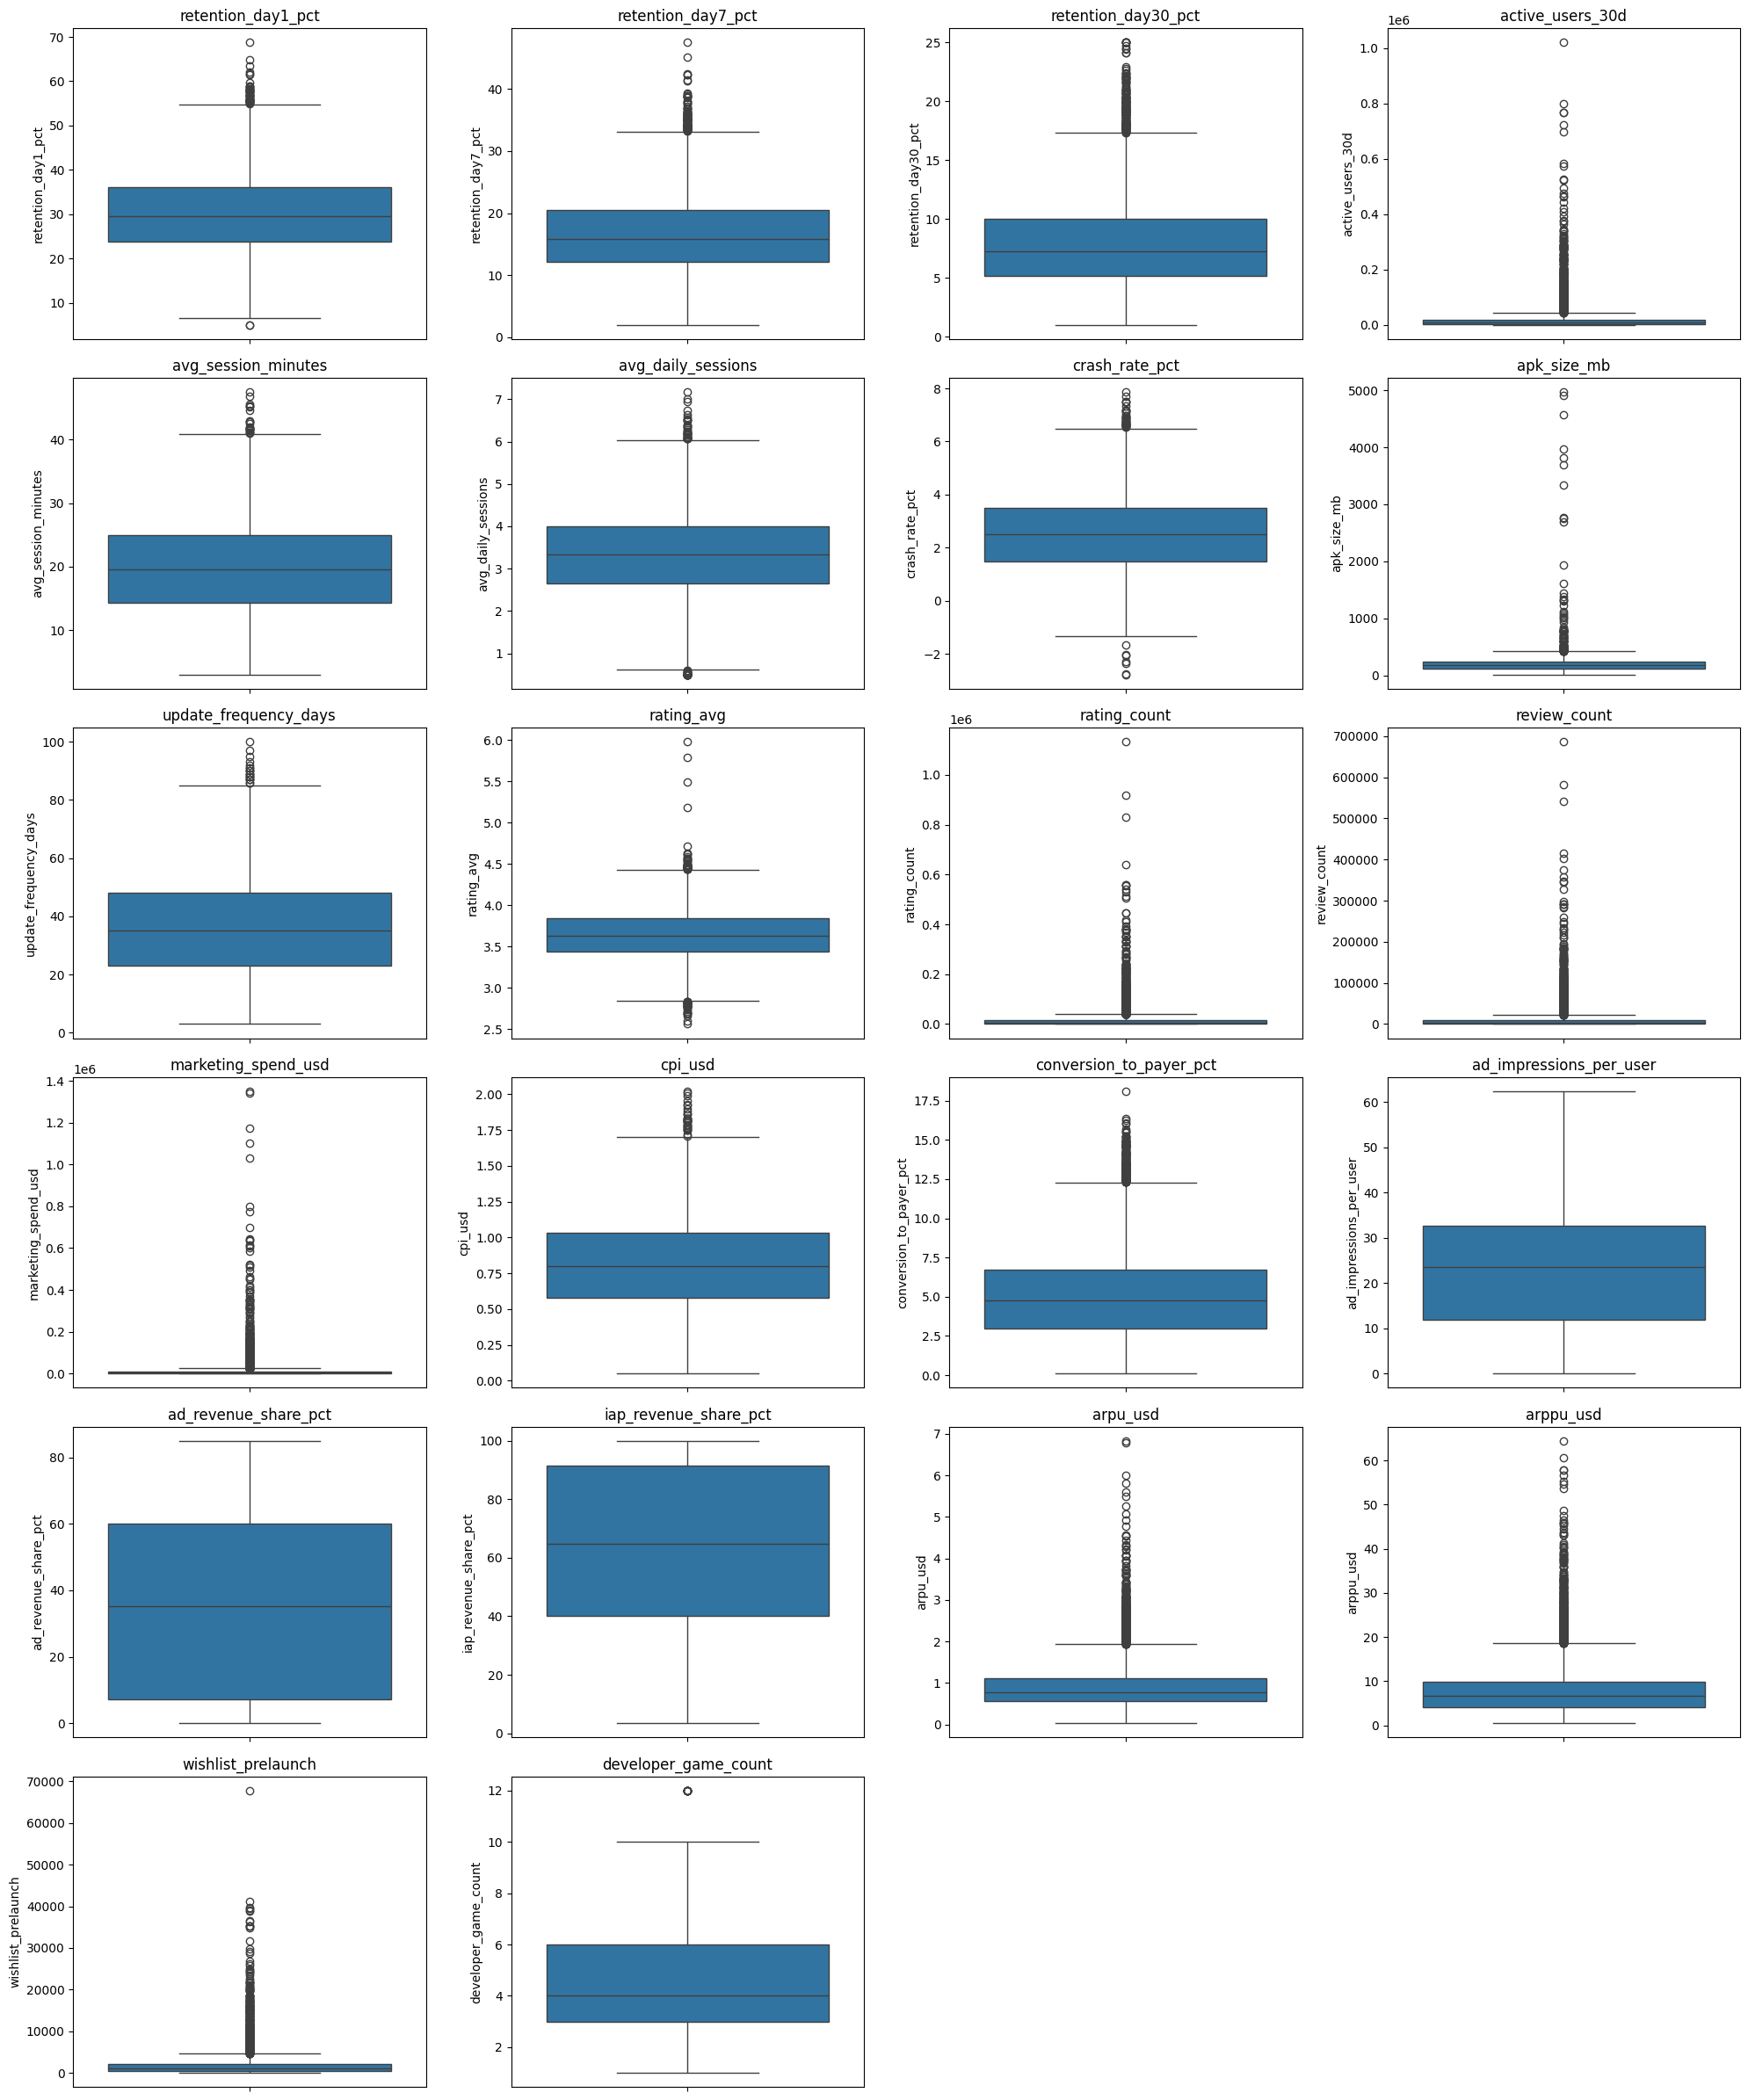

In [59]:
n_cols = 4
n_rows = int(np.ceil(len(num_col_to_cap) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(num_col_to_cap):
    sns.boxplot(y=X_train[col], ax=axes[i])
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

## 9. Cap Outliers (Winsorize)
Values beyond the bounds are pulled to the nearest boundary instead of deleted.
Bounds calculated from **train only** (Section 8), then applied to both train and test.
`price_usd` is skipped here (see Section 8 note).

In [60]:
for col in num_col_to_cap:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X_train[col] = np.clip(X_train[col], lower_bound, upper_bound)
    X_test[col] = np.clip(X_test[col], lower_bound, upper_bound)

## 10. Scale Numeric Features


In [61]:
log_cols = [
    'downloads',
    'active_users_30d',
    'rating_count',
    'review_count',
    'marketing_spend_usd',
    'total_revenue_usd',
    'wishlist_prelaunch',
    'post_30d_revenue_usd',
    'post_30d_rating_count'
]

log_cols = [c for c in log_cols if c in X_train.columns]

for c in log_cols:
    X_train[c] = np.log1p(X_train[c])
    X_test[c] = np.log1p(X_test[c])

In [62]:
standard_cols = [
    'price_usd','retention_day1_pct','retention_day7_pct','retention_day30_pct','avg_session_minutes',
    'avg_daily_sessions','crash_rate_pct','apk_size_mb','update_frequency_days','rating_avg','cpi_usd','conversion_to_payer_pct',
    'ad_impressions_per_user','ad_revenue_share_pct','iap_revenue_share_pct','arpu_usd','arppu_usd','days_since_release','days_since_update',
    'days_since_soft_launch', 'featured_gap_days', 'developer_game_count'
]

standard_cols = [c for c in standard_cols if c in X_train.columns]

standard_scaler = StandardScaler()

X_train[standard_cols] = standard_scaler.fit_transform(
    X_train[standard_cols]
)

X_test[standard_cols] = standard_scaler.transform(
    X_test[standard_cols]
)


## 12.encoding
`drop_first=True` drops one category per column to avoid perfectly collinear dummy columns
(important for linear/logistic regression; harmless but unnecessary for tree models).

In [63]:
X_train[['genre', 'sub_genre', 'monetization_model', 'contains_ads',
            'has_in_app_purchases', 'age_rating',
            'art_style', 'engine_used', 'region_focus', 'publisher_tier',
            'country_code_primary']]

,genre,sub_genre,monetization_model,contains_ads,has_in_app_purchases,age_rating,art_style,engine_used,region_focus,publisher_tier,country_code_primary
6410,Casual,Party Game,Free,Yes,Yes,Teen,Minimalist,Unity,SEA,Indie,BR
4064,RPG,Dungeon Crawler,Freemium,Yes,No,Teen,3D Realistic,Unity,Europe,Indie,BR
1572,Casual,Party Game,Free,No,Yes,Everyone,Anime,Unity,US,AAA,IN
5249,Racing,Arcade Racing,Freemium,No,Yes,Mature 17+,Anime,Godot,SEA,Indie,IN
7899,RPG,MMORPG,Freemium,Yes,Yes,Teen,Pixel,Unity,Europe,Indie,IN
...,...,...,...,...,...,...,...,...,...,...,...
2554,Puzzle,Sudoku,Free,No,Yes,Everyone,3D Realistic,Unity,Europe,Indie,IN
8665,Racing,Drag Racing,Paid,No,Yes,Everyone,Pixel,Unity,LATAM,Unknown,IN
1992,Simulation,City Builder,Freemium,Yes,Yes,Everyone,Pixel,Godot,SEA,Indie,IN
9859,Action,Battle Royale,Free,Yes,No,Everyone,Minimalist,Unity,Global,Mid-size,BR


In [64]:
cat_cols = [
    'genre',
    'sub_genre',
    'monetization_model',
    'contains_ads',
    'has_in_app_purchases',
    'age_rating',
    'art_style',
    'engine_used',
    'region_focus',
    'publisher_tier',
    'country_code_primary'
]

for col in cat_cols:
    counts = X_train[col].value_counts()

    X_train[col + '_count'] = X_train[col].map(counts)
    X_test[col + '_count'] = X_test[col].map(counts).fillna(0)


X_train = X_train.drop(columns=cat_cols)
X_test = X_test.drop(columns=cat_cols)

In [65]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print("Classes:", le.classes_)
print("y_train:", y_train[:10])

Classes: [0 1]
y_train: [0 0 0 0 0 0 0 0 0 0]


In [66]:
bool_features = X_train.select_dtypes(include = "bool").columns

for col in bool_features:
    X_train[col] = X_train[col].astype(int)
    X_test[col] = X_test[col].astype(int)

## 13. Final Check

In [67]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (8000, 39)
X_test shape: (2000, 39)


In [68]:
X_train

,was_featured_on_store,price_usd,retention_day1_pct,retention_day7_pct,retention_day30_pct,active_users_30d,avg_session_minutes,avg_daily_sessions,crash_rate_pct,apk_size_mb,...,sub_genre_count,monetization_model_count,contains_ads_count,has_in_app_purchases_count,age_rating_count,art_style_count,engine_used_count,region_focus_count,publisher_tier_count,country_code_primary_count
6410,0,-0.386052,2.518619,0.843402,0.164015,9.661925,-2.158706,-1.266341,0.064194,-0.545301,...,480,2833,5199,5493,2765,1630,5291,1335,3989,409
4064,0,-0.386052,-2.125071,-1.879543,-1.560527,7.621195,1.410041,1.733316,-0.786534,0.001369,...,205,3607,5199,2507,2765,1600,5291,1302,3989,409
1572,1,-0.386052,-0.303714,-0.795938,-0.965282,9.839056,-0.611599,0.647914,-0.076422,1.049888,...,480,2833,2801,5493,4434,1640,5291,1289,776,6843
5249,1,-0.386052,-0.162762,0.653239,1.162580,8.721113,-0.827414,-0.151337,0.893830,0.795386,...,211,3607,2801,5493,801,1640,1165,1335,3989,6843
7899,1,-0.386052,2.712427,2.706513,1.421261,9.713235,1.829970,1.358359,-0.273285,-1.373968,...,228,3607,5199,5493,2765,1540,5291,1302,3989,6843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2554,1,-0.386052,1.191693,1.766351,2.629831,10.711160,-0.644101,-0.180939,0.514166,1.994908,...,393,2833,2801,5493,4434,1600,5291,1302,3989,6843
8665,0,1.440292,0.134557,0.559796,0.347595,6.455199,-0.328180,2.424026,0.436828,0.114927,...,190,1184,2801,5493,4434,1540,5291,1345,1202,6843
1992,0,-0.386052,0.100420,-0.833643,-0.884618,7.545918,1.113620,0.973534,-0.343593,-1.235484,...,197,3607,5199,5493,4434,1540,1165,1335,3989,6843
9859,1,-0.386052,-1.214392,-1.115610,-1.324098,8.478868,-0.329480,1.141278,0.591505,0.432803,...,339,2833,5199,2507,4434,1630,5291,1342,2033,409


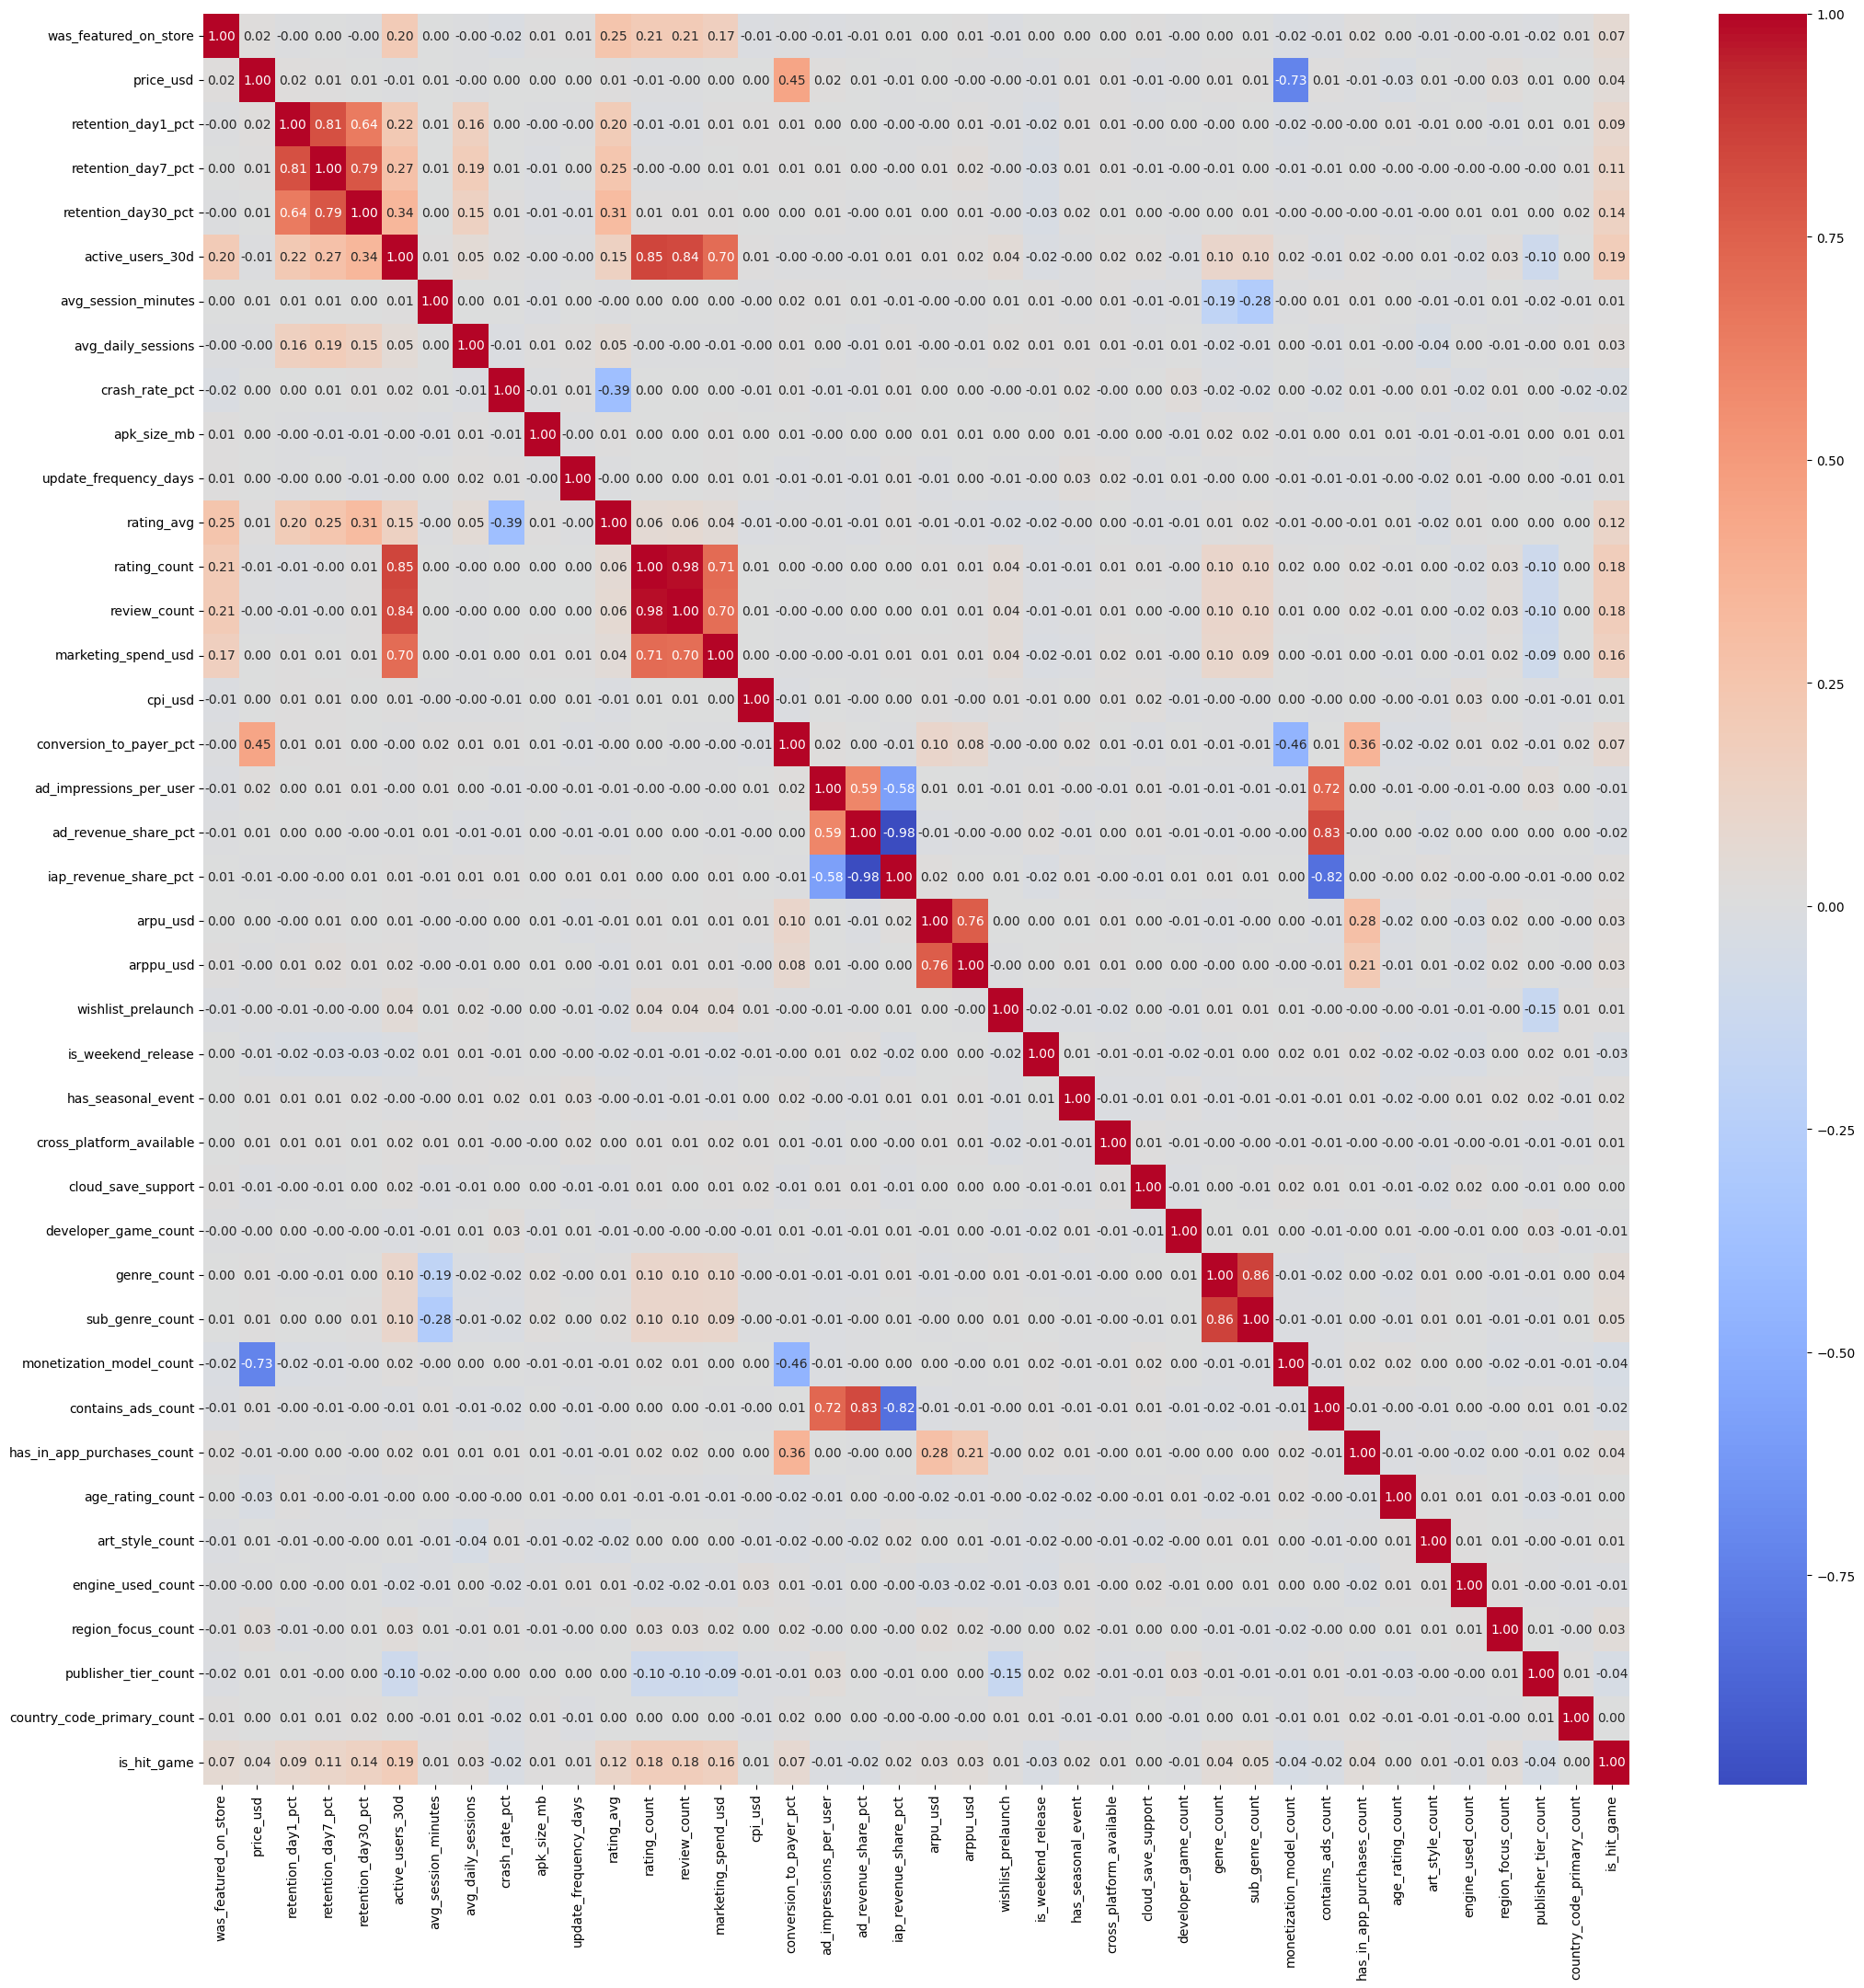

In [69]:
new_data = pd.concat(
    [
        X_train.select_dtypes(include="number").reset_index(drop=True),
        pd.Series(y_train, name="is_hit_game").reset_index(drop=True),
    ],
    axis=1,
)

corr = new_data.corr()
plt.figure(figsize = (25,25))
sns.heatmap(corr,annot = True,fmt = '.2f',cmap="coolwarm")
plt.show()

In [70]:
corr_target = abs(corr["is_hit_game"])

corr_target

,is_hit_game
was_featured_on_store,0.066722
price_usd,0.043471
retention_day1_pct,0.092547
retention_day7_pct,0.111241
retention_day30_pct,0.144094
active_users_30d,0.191989
avg_session_minutes,0.014478
avg_daily_sessions,0.026677
crash_rate_pct,0.023959
apk_size_mb,0.014494


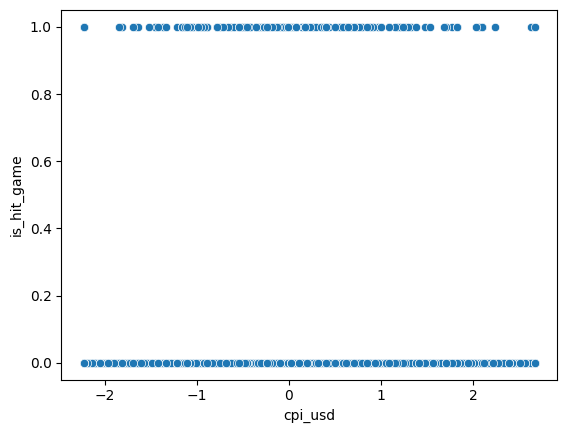

In [71]:
sns.scatterplot(data = new_data ,x = 'cpi_usd' ,y = 'is_hit_game')
plt.show()

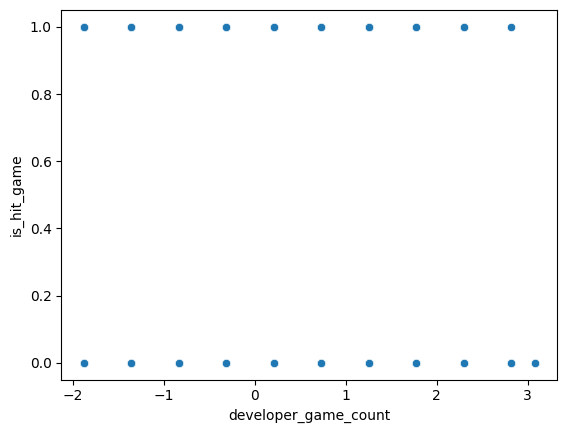

In [72]:
sns.scatterplot(data = new_data ,x = 'developer_game_count' ,y = 'is_hit_game')
plt.show()

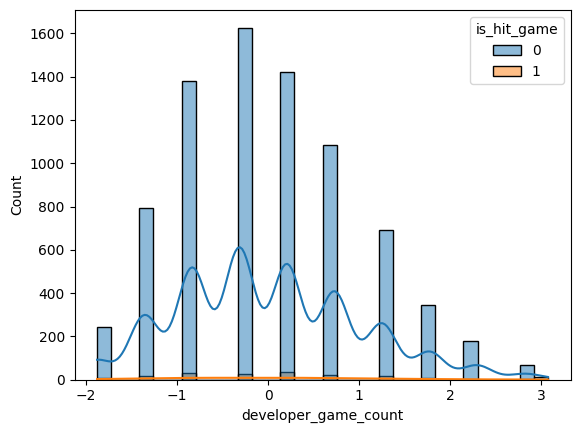

In [73]:
sns.histplot(data=new_data, x='developer_game_count', hue="is_hit_game", kde=True)
plt.show()

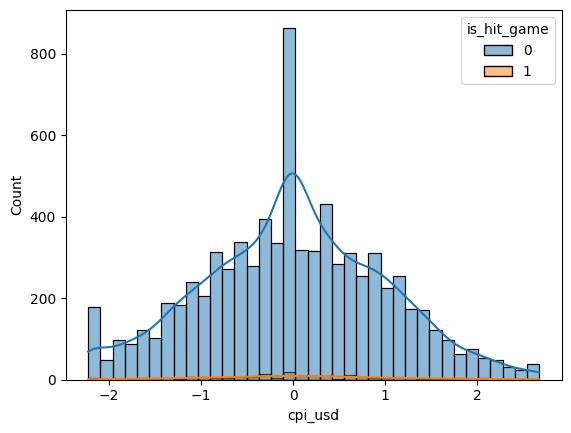

In [74]:
sns.histplot(data=new_data, x='cpi_usd', hue="is_hit_game", kde=True)
plt.show()

In [75]:
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

multi_features = [
    column for column in upper.columns
    if any(upper[column] > 0.7)
]

In [76]:
X_train.drop(
    columns = multi_features ,
    inplace = True

)

In [77]:
X_test.drop(
    columns = multi_features ,
    inplace = True

)

In [78]:
X_train.head()

,was_featured_on_store,price_usd,retention_day1_pct,active_users_30d,avg_session_minutes,avg_daily_sessions,crash_rate_pct,apk_size_mb,update_frequency_days,rating_avg,...,developer_game_count,genre_count,monetization_model_count,has_in_app_purchases_count,age_rating_count,art_style_count,engine_used_count,region_focus_count,publisher_tier_count,country_code_primary_count
6410,0,-0.386052,2.518619,9.661925,-2.158706,-1.266341,0.064194,-0.545301,-0.016294,0.401281,...,-0.314157,1468,2833,5493,2765,1630,5291,1335,3989,409
4064,0,-0.386052,-2.125071,7.621195,1.410041,1.733316,-0.786534,0.001369,-1.045587,0.067454,...,0.207699,931,3607,2507,2765,1600,5291,1302,3989,409
1572,1,-0.386052,-0.303714,9.839056,-0.611599,0.647914,-0.076422,1.049888,-0.530940,1.235847,...,0.729554,1468,2833,5493,4434,1640,5291,1289,776,6843
5249,1,-0.386052,-0.162762,8.721113,-0.827414,-0.151337,0.893830,0.795386,0.498353,0.401281,...,-0.314157,582,3607,5493,801,1640,1165,1335,3989,6843
7899,1,-0.386052,2.712427,9.713235,1.829970,1.358359,-0.273285,-1.373968,-1.445868,1.903500,...,0.729554,931,3607,5493,2765,1540,5291,1302,3989,6843


In [79]:
X_train.shape

(8000, 31)

In [80]:
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X_train, y_train)

mi = pd.Series(
    mi_scores,
    index=X_train .columns
).sort_values(ascending=False)

print(mi)

active_users_30d              0.031354
price_usd                     0.020195
cloud_save_support            0.013829
age_rating_count              0.012110
avg_daily_sessions            0.010647
rating_avg                    0.008869
is_weekend_release            0.008126
has_seasonal_event            0.007909
cpi_usd                       0.007362
ad_revenue_share_pct          0.004442
monetization_model_count      0.003923
apk_size_mb                   0.002782
conversion_to_payer_pct       0.002650
wishlist_prelaunch            0.002639
arpu_usd                      0.002368
cross_platform_available      0.002204
ad_impressions_per_user       0.001561
was_featured_on_store         0.000849
iap_revenue_share_pct         0.000769
retention_day1_pct            0.000370
update_frequency_days         0.000000
avg_session_minutes           0.000000
crash_rate_pct                0.000000
genre_count                   0.000000
developer_game_count          0.000000
has_in_app_purchases_coun

In [81]:
weak_features =  corr_target[corr_target <= 0.02]
weak_features

,is_hit_game
avg_session_minutes,0.014478
apk_size_mb,0.014494
update_frequency_days,0.009390
cpi_usd,0.007713
ad_impressions_per_user,0.013488
wishlist_prelaunch,0.013056
has_seasonal_event,0.017367
cross_platform_available,0.014586
cloud_save_support,0.001251
developer_game_count,0.005740


In [82]:
weak_features = list(weak_features.index)
weak_features

['avg_session_minutes',
 'apk_size_mb',
 'update_frequency_days',
 'cpi_usd',
 'ad_impressions_per_user',
 'wishlist_prelaunch',
 'has_seasonal_event',
 'cross_platform_available',
 'cloud_save_support',
 'developer_game_count',
 'age_rating_count',
 'art_style_count',
 'engine_used_count',
 'country_code_primary_count']

In [83]:
X_train.drop(
    columns = weak_features,
    inplace = True

)

In [84]:
X_test.drop(
    columns = weak_features,
    inplace = True

)

In [85]:
X_test

,was_featured_on_store,price_usd,retention_day1_pct,active_users_30d,avg_daily_sessions,crash_rate_pct,rating_avg,conversion_to_payer_pct,ad_revenue_share_pct,iap_revenue_share_pct,arpu_usd,is_weekend_release,genre_count,monetization_model_count,has_in_app_purchases_count,region_focus_count,publisher_tier_count
2853,0,-0.386052,-0.249756,7.040536,0.963667,-1.707571,1.235847,0.782459,-0.393814,0.471404,-0.080162,0,569,3607,5493,1345,3989
2497,0,-0.386052,-0.737580,6.620073,0.509771,0.261057,1.002168,1.246622,1.023086,-1.020731,-0.369343,0,1496,2833,5493,1289,3989
9564,0,2.177431,-0.464487,8.807023,-0.309214,-0.906058,1.369378,1.498885,-0.335771,0.551150,0.431467,1,582,1184,5493,1345,3989
271,0,0.120044,-0.046037,10.227200,1.940529,-1.081828,0.000689,-0.145867,-1.055058,1.032921,-0.391588,0,1496,376,5493,1302,3989
6334,0,-0.386052,-0.260768,6.893656,0.855127,-1.187290,-0.767113,-0.986743,-1.071957,0.892450,-1.503824,0,1402,3607,2507,1345,3989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3004,0,0.769166,1.392109,8.602453,-0.358550,0.190749,-1.201087,1.165898,0.394536,-0.027925,-1.370356,0,983,1184,2507,1342,3989
1192,1,-0.386052,-0.331243,8.483843,-0.605233,1.723466,-1.034174,-1.417271,1.693147,-2.059994,1.565948,1,569,2833,2507,1289,776
6511,1,0.912193,-0.812460,8.774158,1.457031,0.936015,-0.600199,2.319580,0.922062,-0.669188,-1.081174,0,983,1184,5493,1289,2033
315,1,-0.386052,0.504555,8.750049,-0.338816,-1.313845,0.935403,-1.672897,0.343474,-0.120841,1.098809,0,1468,3607,5493,1302,2033


In [89]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

results = []

def evaluate_model(name, model, X_train, y_train, X_test, y_test, threshold=0.5):
    y_proba_train = model.predict_proba(X_train)[:, 1]
    y_proba_test = model.predict_proba(X_test)[:, 1]

    y_pred_train = (y_proba_train >= threshold).astype(int)
    y_pred = (y_proba_test >= threshold).astype(int)

    metrics = {
        'Model': name,
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
    }

    print(f"{name} (threshold={threshold})")
    print("--- Train ---")
    print(classification_report(y_train, y_pred_train))
    print("Confusion Matrix (Train):")
    print(confusion_matrix(y_train, y_pred_train))

    print("\n--- Test ---")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix (Test):")
    print(confusion_matrix(y_test, y_pred))

    results.append(metrics)
    return model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

results = []

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)
lr = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
evaluate_model("Logistic Regression", lr, X_train, y_train, X_test, y_test, threshold=0.6)
rf = RandomForestClassifier(n_estimators=200, max_depth=20, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test, threshold=0.05)
xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
evaluate_model("XGBoost", xgb, X_train, y_train, X_test, y_test, threshold=0.5)

scale_pos_weight: 49.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression (threshold=0.6)
--- Train ---
              precision    recall  f1-score   support

           0       1.00      0.86      0.93      7840
           1       0.12      0.87      0.20       160

    accuracy                           0.86      8000
   macro avg       0.56      0.87      0.56      8000
weighted avg       0.98      0.86      0.91      8000

Confusion Matrix (Train):
[[6775 1065]
 [  21  139]]

--- Test ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.93      1960
           1       0.11      0.82      0.19        40

    accuracy                           0.86      2000
   macro avg       0.55      0.84      0.56      2000
weighted avg       0.98      0.86      0.91      2000

Confusion Matrix (Test):
[[1693  267]
 [   7   33]]
Random Forest (threshold=0.5)
--- Train ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7840
 

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

## 16. Final Comparison


                 Model  Threshold  Accuracy  Precision  Recall      F1
0              XGBoost        0.5     0.976      0.400   0.400  0.4000
1        Random Forest        0.5     0.983      0.875   0.175  0.2917
2  Logistic Regression        0.6     0.863      0.110   0.825  0.1941

Best model (by F1-score): XGBoost


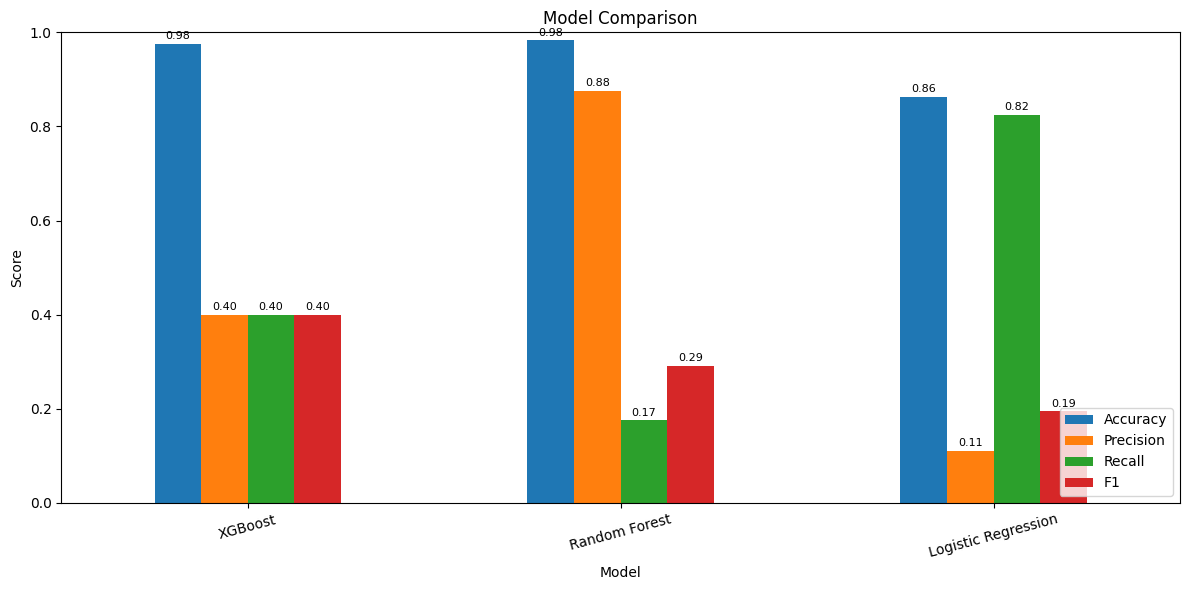

In [88]:
results_df = pd.DataFrame(results).sort_values(
    by='F1',
    ascending=False
).reset_index(drop=True)

print(results_df.round(4))

best_model_name = results_df.iloc[0]['Model']

print(f"\nBest model (by F1-score): {best_model_name}")

ax = results_df.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1']
].plot(
    kind='bar',
    figsize=(12, 6),
    ylim=(0, 1)
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()